# Hyperparamater Tuning




---
#### Imports 
Import neccessary components.

---

In [23]:
# Import necessary libraries.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time
import keras_tuner as kt
import tensorflow as tf
import tensorflow.keras.backend as K
import os
import random
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
LabelEncoder

from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier

from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD, Adagrad, RMSprop, Adadelta
from tensorflow.keras.layers import Input, Dense , Dropout
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LeakyReLU
from IPython.display import Markdown, display
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

!pip install tabulate

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\NedMatheson\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


---
## Data Preprocessing

1. Load Dataset
1. Remove Invalid Column
1. Test Train Validation split
1. Scale the data to aid neural network performance

---

In [24]:
# Load the dataset from the CSV file into a pandas DataFrame.
#d = pd.read_csv("../Data/NZ_LUCAS_SMAP_NIWA.csv")
df= pd.read_csv("C:\\Python\\COMP661 Deep Learning\\Comp661_Assigment1\\1174976_EcoVision_Project1\\Data\\NZ_LUCAS_SMAP_NIWA.csv")
# Drop the unnecessary column '36' from the dataframe.
df.drop(columns=['36'], inplace=True)

# Target
y = df["soil_organic_carbon_target"]

# Features (Drop soil_organic_carbon_target from the features)
X = df.drop(columns=["soil_organic_carbon_target"])


# Train (70%) / Temp (30%)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Validation (15%) / Test (15%)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

# Scale the data to aid neural network training.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)


#Verify the shapes of the training, validation, and test sets, as well as the mean and standard deviation of the scaled training set.
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print('X_train_scaled mean:', X_train_scaled.mean())
print('X_train_scaled standard deviation:', X_train_scaled.std())

Training set: (3500, 35)
Validation set: (750, 35)
Test set: (750, 35)
X_train_scaled mean: -5.977259503679863e-17
X_train_scaled standard deviation: 1.0


---
### Create Baseline Model

#### Compile the model using:

* Loss Function: Mean Squared Error (MSE)
* Optimizer: Adam (default learning rate)
* Evaluation Metric: Mean Absolute Error (MAE)

#### Train the model using:


* Epochs: 100
* Batch size: 32
* Validation set: created in Part 1

---

In [ ]:


# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
epoch_num = 100

baseline_model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        32,
        activation='relu',
        input_shape=(X_train_scaled.shape[1],)
    ),
    tf.keras.layers.Dense(1)
])

baseline_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=epoch_num,
    batch_size=32,
    verbose=1
)

Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3811.3845 - mae: 60.9778 - val_loss: 3582.2793 - val_mae: 59.0345
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3329.8606 - mae: 56.9114 - val_loss: 2998.5779 - val_mae: 53.9210


---
### Evaluate baseline model

---

In [26]:
test_loss, test_mae = baseline_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

Test MSE: 3006.69677734375
Test MAE: 54.06674575805664


---
### Training History Plot, Baseline Model

Training vs Validation loss 

---

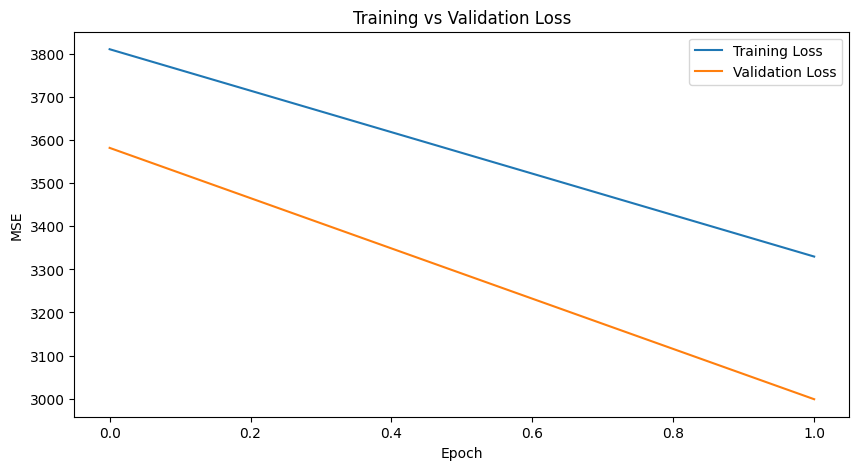

In [27]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

---
#### Create Resuable Function

Now Works with Leaky_Relu

---

In [28]:

# Create Reusable Function to Create Dynamic Model.

def create_dynamic_model(num_hidden_layers,
                         num_neurons,
                         activation_choice,
                         optimizer_choice):

    model = Sequential()

    # First hidden layer added for leaky_relu
    if activation_choice == 'leaky_relu':
        model.add(Dense(num_neurons, input_shape=(X_train_scaled.shape[1],)))
        model.add(LeakyReLU(negative_slope=0.01))
    else:
        model.add(Dense(num_neurons,
                        activation=activation_choice,
                        input_shape=(X_train_scaled.shape[1],)))

    # Remaining hidden layers
    for _ in range(num_hidden_layers - 1):

        if activation_choice == 'leaky_relu':
            model.add(Dense(num_neurons))
            model.add(LeakyReLU(negative_slope=0.01))
        else:
            model.add(Dense(num_neurons,
                            activation=activation_choice))

    # Output layer for regression
    model.add(Dense(1))

    model.compile(
        optimizer=optimizer_choice,
        loss='mse',
        metrics=['mae']
    )

    return model


#Before I break things with LeakyReLU
""""
def create_dynamic_model(
    num_hidden_layers,
    num_neurons,
    activation_choice,
    optimizer_choice
):

    model = tf.keras.Sequential()

    model.add(
        tf.keras.layers.Input(
            shape=(X_train_scaled.shape[1],)
        )
    )

    for _ in range(num_hidden_layers):
        model.add(
            tf.keras.layers.Dense(
                num_neurons,
                activation=activation_choice
            )
        )

    model.add(tf.keras.layers.Dense(1))

    model.compile(
        optimizer=optimizer_choice,
        loss='mse',
        metrics=['mae']
    )

    return model
"""

'"\ndef create_dynamic_model(\n    num_hidden_layers,\n    num_neurons,\n    activation_choice,\n    optimizer_choice\n):\n\n    model = tf.keras.Sequential()\n\n    model.add(\n        tf.keras.layers.Input(\n            shape=(X_train_scaled.shape[1],)\n        )\n    )\n\n    for _ in range(num_hidden_layers):\n        model.add(\n            tf.keras.layers.Dense(\n                num_neurons,\n                activation=activation_choice\n            )\n        )\n\n    model.add(tf.keras.layers.Dense(1))\n\n    model.compile(\n        optimizer=optimizer_choice,\n        loss=\'mse\',\n        metrics=[\'mae\']\n    )\n\n    return model\n'

In [29]:

#Test Super loop I was diverted by


#Arrays for testing loop to be commented out for final submission
#hidden_layers = [1, 2]
#num_neurons = [8, 16]
#activation_array = ['relu', 'tanh']
#optimizer_choice = ['adam', 'sgd']
"""""
for h in hidden_layers:
    print(f"Training model with {h} hidden layers...")
    for n in num_neurons:
        print(f"Number of neurons: {n}")
    for a in activation_array:
        print(f"Activation function: {a}")
    for o in optimizer_choice:
        print(f"Optimizer: {o}")
        model = create_dynamic_model(num_hidden_layers=h , num_neurons=n, activation_choice=a, optimizer_choice=o)
        
        history = model.fit(
            X_train_scaled,
            y_train,
            validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=32,
        verbose=1
    )
    
    test_loss, test_mae = model.evaluate(
        X_test_scaled,
        y_test,
        verbose=0
    )
    
    print(f"Test MSE for {h} hidden layers: {test_loss}")
    print(f"Test MAE for {h} hidden layers: {test_mae}")
    
    plt.figure(figsize=(10,5))
    
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Training vs Validation Loss for {h} Hidden Layers")
    plt.legend()
    
    plt.show()

    """


'""\nfor h in hidden_layers:\n    print(f"Training model with {h} hidden layers...")\n    for n in num_neurons:\n        print(f"Number of neurons: {n}")\n    for a in activation_array:\n        print(f"Activation function: {a}")\n    for o in optimizer_choice:\n        print(f"Optimizer: {o}")\n        model = create_dynamic_model(num_hidden_layers=h , num_neurons=n, activation_choice=a, optimizer_choice=o)\n\n        history = model.fit(\n            X_train_scaled,\n            y_train,\n            validation_data=(X_val_scaled, y_val),\n        epochs=100,\n        batch_size=32,\n        verbose=1\n    )\n\n    test_loss, test_mae = model.evaluate(\n        X_test_scaled,\n        y_test,\n        verbose=0\n    )\n\n    print(f"Test MSE for {h} hidden layers: {test_loss}")\n    print(f"Test MAE for {h} hidden layers: {test_mae}")\n\n    plt.figure(figsize=(10,5))\n\n    plt.plot(history.history[\'loss\'], label=\'Training Loss\')\n    plt.plot(history.history[\'val_loss\'], labe

---
### Hidden Layer Loop



Loop through the hidden layers 1-4 with the same number of neurons (32), activation_choice (relu ) and optimizer_choice (adam)

---

Training model with 1 hidden layers...


Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3802.6772 - mae: 60.9118 - val_loss: 3584.8247 - val_mae: 59.0630
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3346.4685 - mae: 57.0647 - val_loss: 3027.7759 - val_mae: 54.2044
Validation MSE for 1 hidden layers: 3027.77587890625
Validation MAE for 1 hidden layers: 54.20443344116211


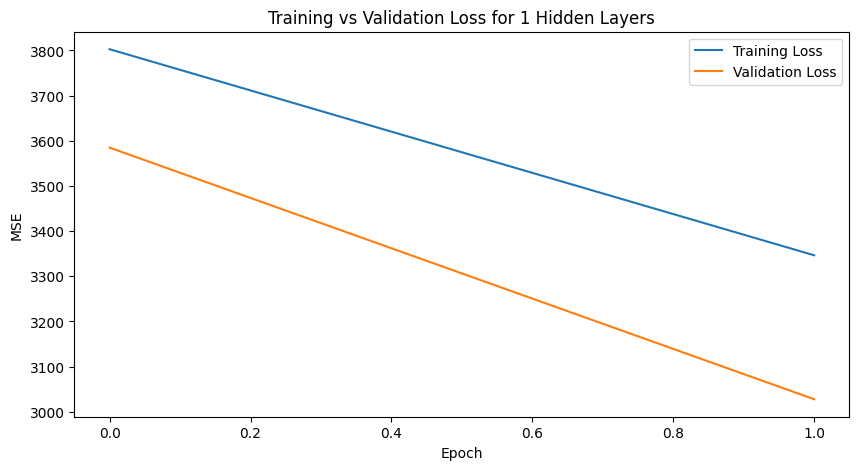

Training model with 2 hidden layers...
Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3256.8359 - mae: 56.0157 - val_loss: 1980.6942 - val_mae: 43.2861
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 747.6920 - mae: 23.3329 - val_loss: 176.8792 - val_mae: 10.8528
Validation MSE for 2 hidden layers: 176.8792266845703
Validation MAE for 2 hidden layers: 10.852812767028809


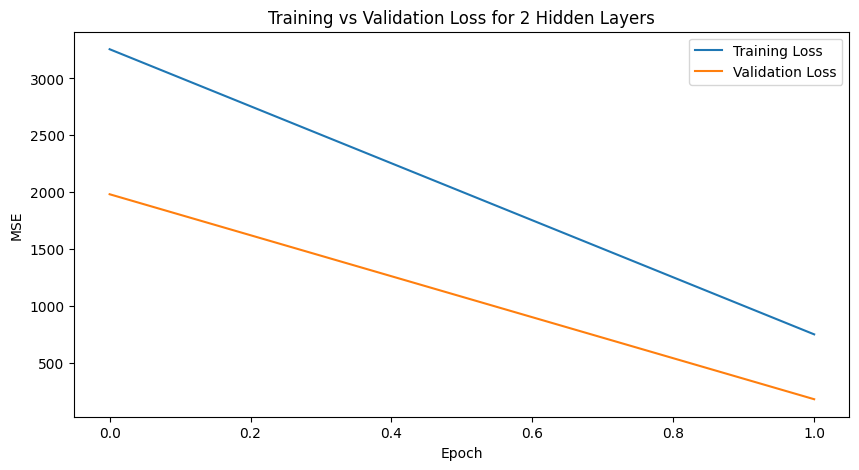

Training model with 3 hidden layers...
Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2815.8164 - mae: 49.9821 - val_loss: 263.2510 - val_mae: 13.2695
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 146.8711 - mae: 9.6840 - val_loss: 117.7527 - val_mae: 8.7106
Validation MSE for 3 hidden layers: 117.75270080566406
Validation MAE for 3 hidden layers: 8.710640907287598


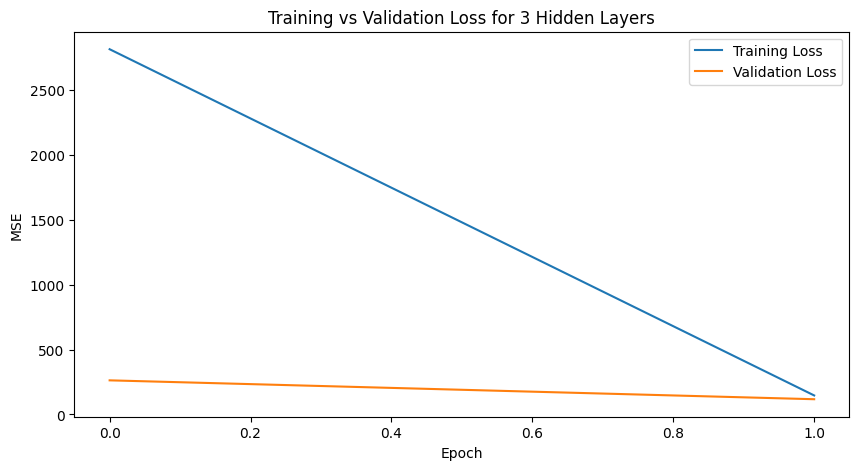

Training model with 4 hidden layers...
Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2185.2607 - mae: 40.5762 - val_loss: 165.4547 - val_mae: 10.3171
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 123.7029 - mae: 8.8465 - val_loss: 105.7897 - val_mae: 8.1747
Validation MSE for 4 hidden layers: 105.78965759277344
Validation MAE for 4 hidden layers: 8.17466926574707


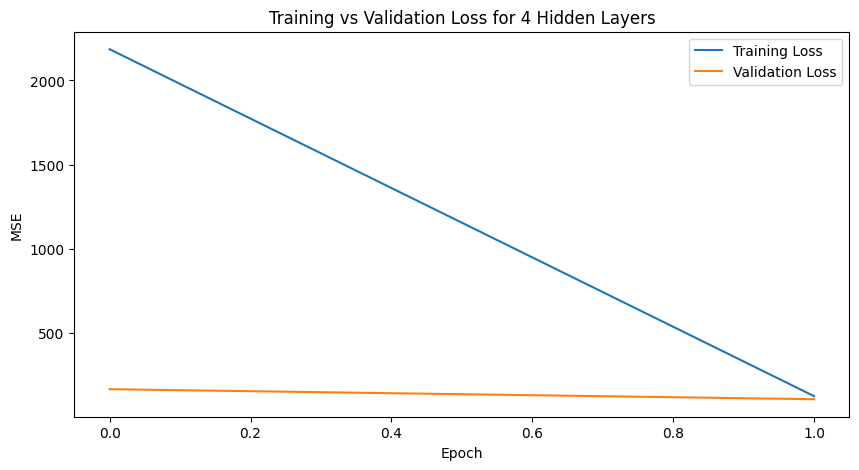


### Results for different hidden layers

|   Variable |   Validation MSE |   Validation MAE |
|-----------:|-----------------:|-----------------:|
|          1 |         3027.78  |         54.2044  |
|          2 |          176.879 |         10.8528  |
|          3 |          117.753 |          8.71064 |
|          4 |          105.79  |          8.17467 |

4 hidden layers had the best results with the lowest validation MSE of 105.789658 and validation MAE of 8.174669.


In [30]:
# Zero results

results = []

# Dataframe to store all results from each hyperparameter combination.
results_total =  pd.DataFrame(
    results,
    columns=[
        "Variable",
        "Validation MSE",
        "Validation MAE"
    ]
)

# Hidden layers loop
# Hidden layers array for the loop
hidden_layers = [1, 2, 3, 4]
# Data Frame to store results for the current hyperparameter being testeds
results_df=  pd.DataFrame(
    results,
    columns=[
        "Variable",
        "Validation MSE",
        "Validation MAE"
    ]
)

# Help with the results dataframe, clear it before starting the loop to avoid appending to old results.
results_df = results_df.iloc[0:0]
results_df.loc[len(results_df)] = ['Hidden Layers Depth', '', '']


# Start the loop to train models with different numbers of hidden layers and record their performance.
for h in hidden_layers:
    print(f"Training model with {h} hidden layers...")
    model = create_dynamic_model(num_hidden_layers=h , num_neurons=32, activation_choice='relu', optimizer_choice='adam')
        
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=epoch_num,
        #epochs=5,
        batch_size=32,
        verbose=1
    )

    val_loss, val_mae = model.evaluate(
        X_val_scaled, 
        y_val, 
        verbose=0
    )
    # Print the validation MSE and MAE for the current number of hidden layers.
    print(f"Validation MSE for {h} hidden layers: {val_loss}")
    print(f"Validation MAE for {h} hidden layers: {val_mae}")

    # Plot the training and validation loss for the current number of hidden layers.
    plt.figure(figsize=(10,5))
    
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Training vs Validation Loss for {h} Hidden Layers")
    plt.legend()
    plt.show()
    # Add row to results dataframe
    results_df.loc[len(results_df)] = [h, val_loss, val_mae]
    #End of loop for hidden layers.

# Add current results to the total results dataframe.
results_total =pd.concat([results_total, results_df], ignore_index=True)

#print("Results for different hidden layers:")
#print(results_df)

# Print the table of results for differnent hidden layers in markup.
from IPython.display import Markdown, display

# Ignore the title row
numeric_rows = results_df[
    pd.to_numeric(
        results_df["Validation MSE"],
        errors="coerce"
    ).notna()
]

best_row = numeric_rows.loc[
    numeric_rows["Validation MSE"].idxmin()
]

markdown_text = f"""
### Results for different hidden layers

{numeric_rows.to_markdown(index=False)}

{int(best_row['Variable'])} hidden layers had the best results with the lowest validation MSE of {best_row['Validation MSE']:.6f} and validation MAE of {best_row['Validation MAE']:.6f}.
"""

display(Markdown(markdown_text))


# Assigen the depth_winner variable.
depth_winner = int(
    numeric_rows.loc[
        numeric_rows["Validation MSE"].idxmin(),
        "Variable"
    ]
)

---

The Hidden Layer Winner will be passed forward.

---

---
### Number of Neurons Loop

---

Training model with 8 number of neurons...
Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3963.3760 - mae: 62.2075 - val_loss: 3703.1057 - val_mae: 59.9940
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2426.8188 - mae: 46.4704 - val_loss: 779.6165 - val_mae: 23.5438
Validation MSE for 8 neurons: 779.6165161132812
Validation MAE for 8 neurons: 23.543779373168945


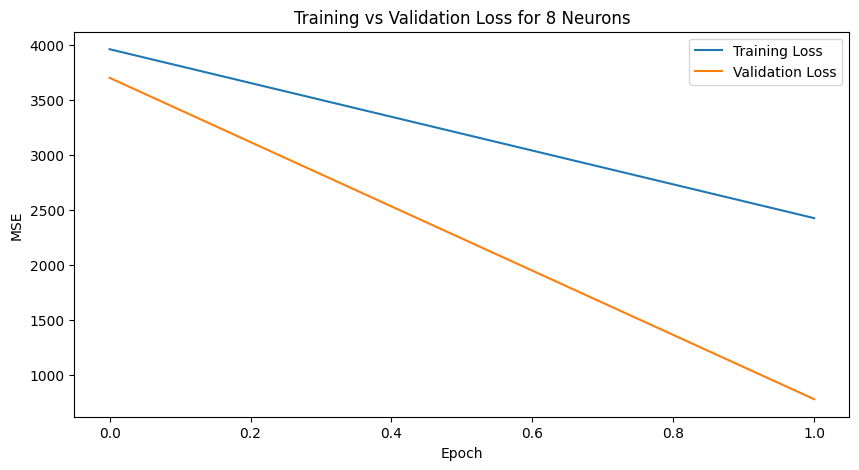

Training model with 16 number of neurons...
Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3438.7825 - mae: 57.5741 - val_loss: 1516.3951 - val_mae: 37.4319
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 373.0687 - mae: 15.3700 - val_loss: 162.4509 - val_mae: 10.2641
Validation MSE for 16 neurons: 162.4508514404297
Validation MAE for 16 neurons: 10.264084815979004


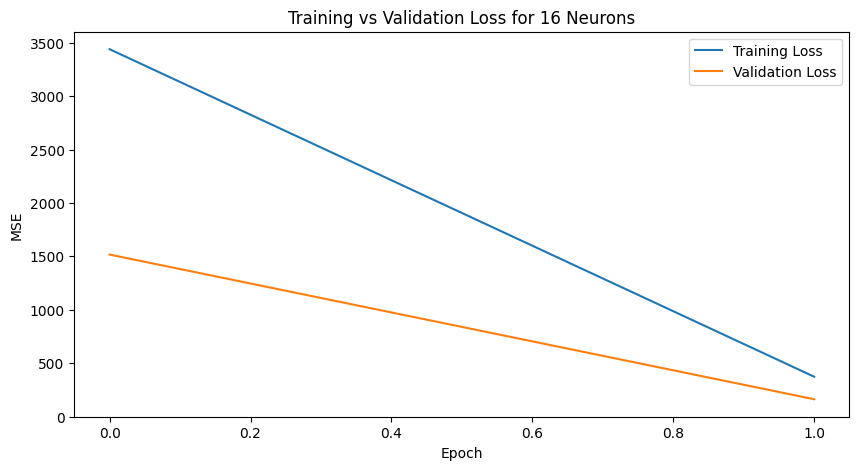

Training model with 32 number of neurons...
Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2794.6692 - mae: 48.5248 - val_loss: 259.1481 - val_mae: 12.3183
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 127.9711 - mae: 9.0506 - val_loss: 118.0940 - val_mae: 8.5588
Validation MSE for 32 neurons: 118.09403991699219
Validation MAE for 32 neurons: 8.558758735656738


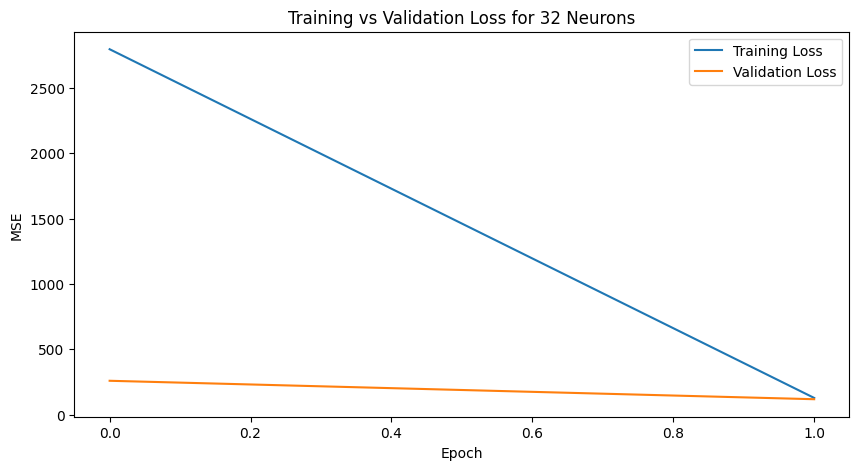

Training model with 64 number of neurons...
Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1408.0834 - mae: 28.5326 - val_loss: 103.6897 - val_mae: 8.1405
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 85.6499 - mae: 7.4074 - val_loss: 87.1813 - val_mae: 7.3848
Validation MSE for 64 neurons: 87.18133544921875
Validation MAE for 64 neurons: 7.384803295135498


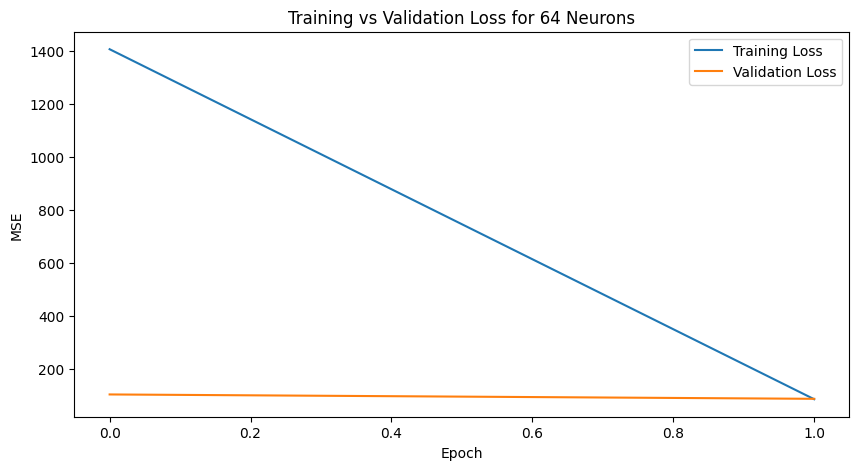

Training model with 128 number of neurons...
Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 718.7079 - mae: 18.0996 - val_loss: 93.2641 - val_mae: 7.7293
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 73.9227 - mae: 6.8431 - val_loss: 79.9520 - val_mae: 7.1504
Validation MSE for 128 neurons: 79.95198059082031
Validation MAE for 128 neurons: 7.150404930114746


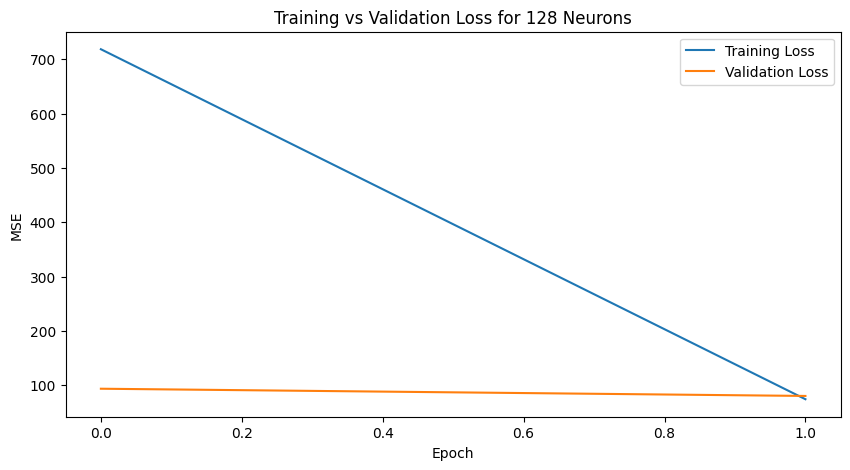


### Results for different neuron numbers

|   Variable |   Validation MSE |   Validation MAE |
|-----------:|-----------------:|-----------------:|
|          8 |         779.617  |         23.5438  |
|         16 |         162.451  |         10.2641  |
|         32 |         118.094  |          8.55876 |
|         64 |          87.1813 |          7.3848  |
|        128 |          79.952  |          7.1504  |

128 number of neurons had the best results with the lowest validation MSE of 79.951981 and validation MAE of 7.150405.


In [31]:
# Hardcoded depth_winner from creation and testing now happens at end of the hidden layer loop.
# Depth_winner = 3
# Depth_winner = results_df.loc[results_df["Validation MSE"].idxmin()]["Variable"]

# Array of different numbers of neurons to test in the next loop.
num_neurons = [8, 16, 32, 64, 128]

# Setup Dataframe to store results for the current hyperparameter being tested.
results_df = pd.DataFrame(
    results,
    columns=[
        "Variable",
        "Validation MSE",
        "Validation MAE"
    ]
)
results_df = results_df.iloc[0:0]
results_df.loc[len(results_df)] = ['Number of Neurons', '', '']


# Run thhe Nerons Loop testing all the number of neurons.
for n in num_neurons:
    print(f"Training model with {n} number of neurons...")
    model = create_dynamic_model(num_hidden_layers=depth_winner , num_neurons=n, activation_choice='relu', optimizer_choice='adam')
        
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=epoch_num,
        batch_size=32,
        verbose=1
    )
    val_loss, val_mae = model.evaluate(
        X_val_scaled, 
        y_val, 
        verbose=0
    )
    # Print the validation MSE and MAE for the current number of neurons.
    print(f"Validation MSE for {n} neurons: {val_loss}")
    print(f"Validation MAE for {n} neurons: {val_mae}")
    
    plt.figure(figsize=(10,5))
    
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Training vs Validation Loss for {n} Neurons")
    plt.legend()
    plt.show()
    results_df.loc[len(results_df)] = [n, val_loss, val_mae]
# Add current results to the total results dataframe.
results_total =pd.concat([results_total, results_df], ignore_index=True)
#print("Results for different neuron numbers:")
#print(results_df)

# Print the table of results for differnent neuron numbers in markup.
# Ignore the title row
numeric_rows = results_df[pd.to_numeric(results_df["Validation MSE"], errors="coerce").notna()]

best_row = numeric_rows.loc[numeric_rows["Validation MSE"].idxmin()]

markdown_text = f"""
### Results for different neuron numbers

{numeric_rows.to_markdown(index=False)}

{int(best_row['Variable'])} number of neurons had the best results with the lowest validation MSE of {best_row['Validation MSE']:.6f} and validation MAE of {best_row['Validation MAE']:.6f}.
"""

display(Markdown(markdown_text))

# Assign the neurons_winner variable.
neurons_winner = int(
    numeric_rows.loc[
        numeric_rows["Validation MSE"].idxmin(),
        "Variable"
    ]
)

---
### Activation funtion Loop

---

Training model with relu activation function...
Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 769.6003 - mae: 18.8991 - val_loss: 98.5438 - val_mae: 7.9494
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 72.9960 - mae: 6.7895 - val_loss: 83.1210 - val_mae: 7.3342
Validation MSE for relu activation function: 83.12101745605469
Validation MAE for relu activation function: 7.334155559539795


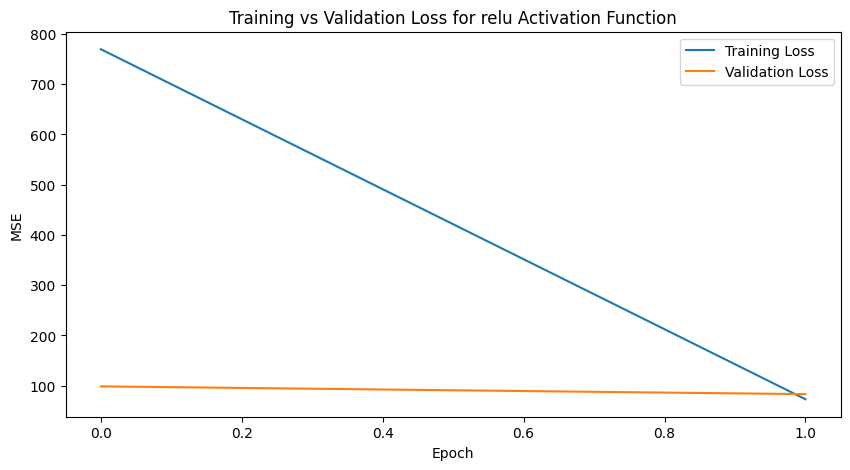

Training model with leaky_relu activation function...
Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 704.2602 - mae: 17.9275 - val_loss: 100.3889 - val_mae: 8.0213
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 74.3627 - mae: 6.8416 - val_loss: 83.9974 - val_mae: 7.3481
Validation MSE for leaky_relu activation function: 83.99744415283203
Validation MAE for leaky_relu activation function: 7.348142147064209


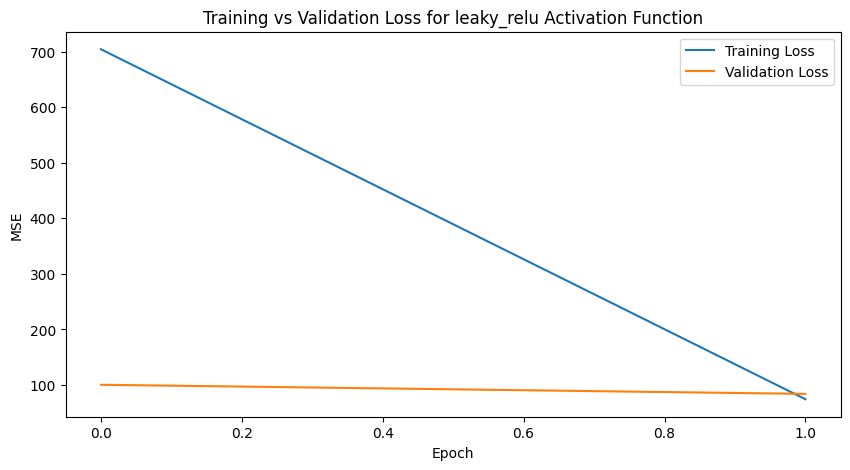

Training model with tanh activation function...
Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2587.3069 - mae: 48.8893 - val_loss: 1235.3013 - val_mae: 33.7104
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 830.8085 - mae: 26.9611 - val_loss: 522.0222 - val_mae: 20.7160
Validation MSE for tanh activation function: 522.022216796875
Validation MAE for tanh activation function: 20.716005325317383


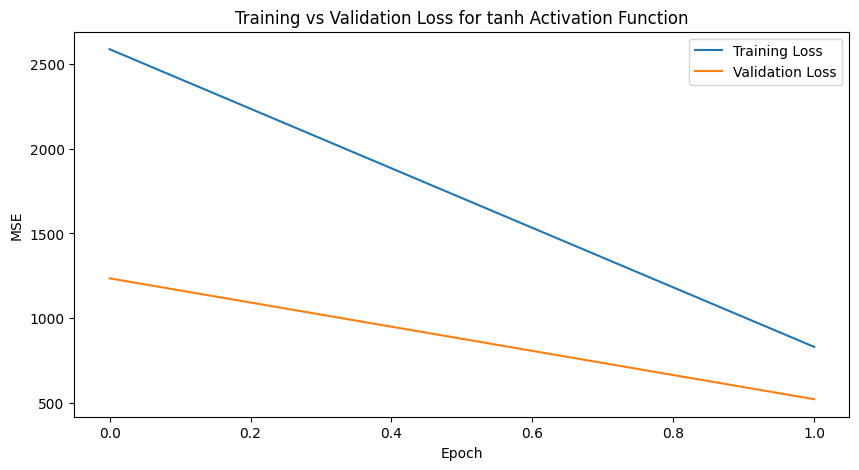

Training model with elu activation function...
Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 891.2695 - mae: 20.7307 - val_loss: 72.1434 - val_mae: 6.7791
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 51.4931 - mae: 5.7171 - val_loss: 46.9497 - val_mae: 5.4804
Validation MSE for elu activation function: 46.94970703125
Validation MAE for elu activation function: 5.480355262756348


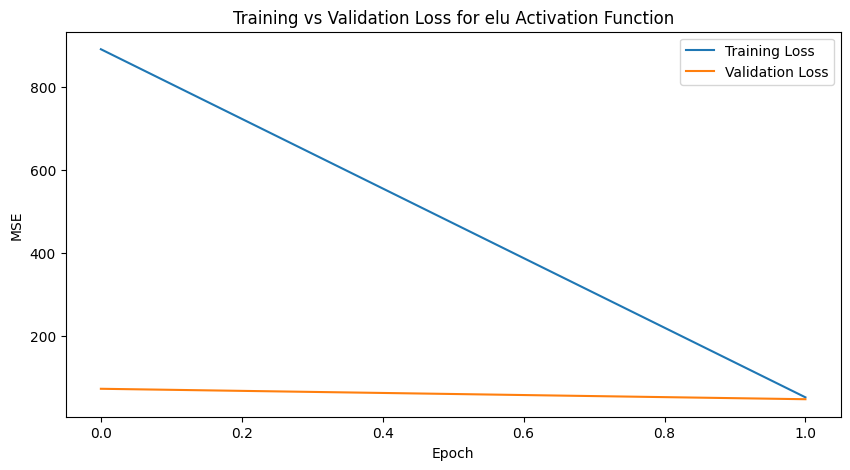

Training model with swish activation function...
Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1147.6868 - mae: 25.2363 - val_loss: 130.5705 - val_mae: 9.3204
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 72.7532 - mae: 6.7219 - val_loss: 55.8390 - val_mae: 6.0167
Validation MSE for swish activation function: 55.839012145996094
Validation MAE for swish activation function: 6.01669979095459


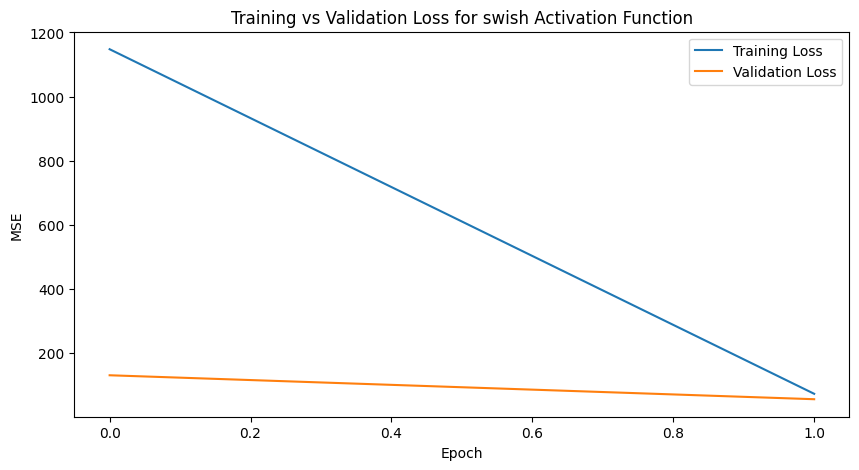


### Results for different activation functions

| Variable   |   Validation MSE |   Validation MAE |
|:-----------|-----------------:|-----------------:|
| relu       |          83.121  |          7.33416 |
| leaky_relu |          83.9974 |          7.34814 |
| tanh       |         522.022  |         20.716   |
| elu        |          46.9497 |          5.48036 |
| swish      |          55.839  |          6.0167  |

elu activation function had the best results with the lowest validation MSE of 46.949707 and validation MAE of 5.480355.


elu


In [32]:
#neurons_winner = 8

# Setup activation function array and results dataframe for the next loop.
activation_array = ['relu', 'leaky_relu','tanh','elu','swish']

# Setup Dataframe to store results for the activation function being tested.
results_df = pd.DataFrame(
    results,
    columns=[
        "Variable",
        "Validation MSE",
        "Validation MAE"
    ]
)
results_df.loc[len(results_df)] = ['Activation Function', '', '']


#Run the Activation Function Loop testing all the activation functions.
for a in activation_array:
    print(f"Training model with {a} activation function...")
    model = create_dynamic_model(num_hidden_layers=depth_winner , num_neurons=neurons_winner, activation_choice=a, optimizer_choice='adam')
        
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=epoch_num,
        batch_size=32,
        verbose=1
    )
    
    val_loss, val_mae = model.evaluate(
        X_val_scaled, 
        y_val, 
        verbose=0
    )
    # Print the validation MSE and MAE for the current activation function.
    print(f"Validation MSE for {a} activation function: {val_loss}")
    print(f"Validation MAE for {a} activation function: {val_mae}")
        # Plot the training and validation loss for the current activation function.
    plt.figure(figsize=(10,5))
    
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Training vs Validation Loss for {a} Activation Function")
    plt.legend()
    plt.show()
    # Add row to results dataframe.
    results_df.loc[len(results_df)] = [a, val_loss, val_mae]
results_total =pd.concat([results_total, results_df], ignore_index=True)
#print("Results for different activation functions:")
#print(results_df)

#Dropping int from best_row['Variable'] to avoid error with LeakyReLU
# Ignore the title row
numeric_rows = results_df[pd.to_numeric(results_df["Validation MSE"], errors="coerce").notna()]
# Display the new dataframe for activation functions in markup.
best_row = numeric_rows.loc[numeric_rows["Validation MSE"].idxmin()]

markdown_text = f"""
### Results for different activation functions

{numeric_rows.to_markdown(index=False)}

{(best_row['Variable'])} activation function had the best results with the lowest validation MSE of {best_row['Validation MSE']:.6f} and validation MAE of {best_row['Validation MAE']:.6f}.
"""

display(Markdown(markdown_text))

# Declare the activation_winner variable to store the best activation function based on the lowest validation MSE.
activation_winner = numeric_rows.loc[
    numeric_rows["Validation MSE"].idxmin(),
    "Variable"
]

print(activation_winner)

---
### Optimizer Array Loop.

---

Training model with adam optimizer...


Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 879.5240 - mae: 20.6429 - val_loss: 74.8093 - val_mae: 6.8449
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 53.4366 - mae: 5.8566 - val_loss: 48.9473 - val_mae: 5.5459
Validation MSE for adam optimizer: 48.9472541809082
Validation MAE for adam optimizer: 5.545867919921875


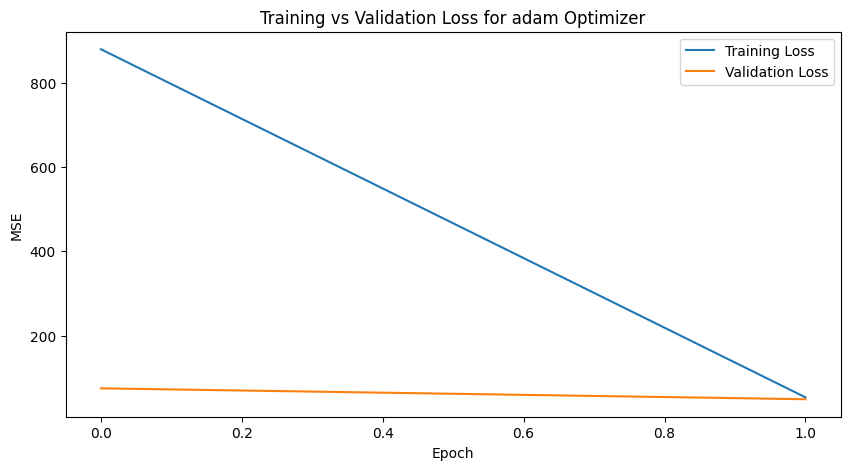

Training model with adamax optimizer...
Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1488.4280 - mae: 30.1026 - val_loss: 81.4725 - val_mae: 7.2754
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 60.6029 - mae: 6.1831 - val_loss: 66.2634 - val_mae: 6.5693
Validation MSE for adamax optimizer: 66.26339721679688
Validation MAE for adamax optimizer: 6.569303512573242


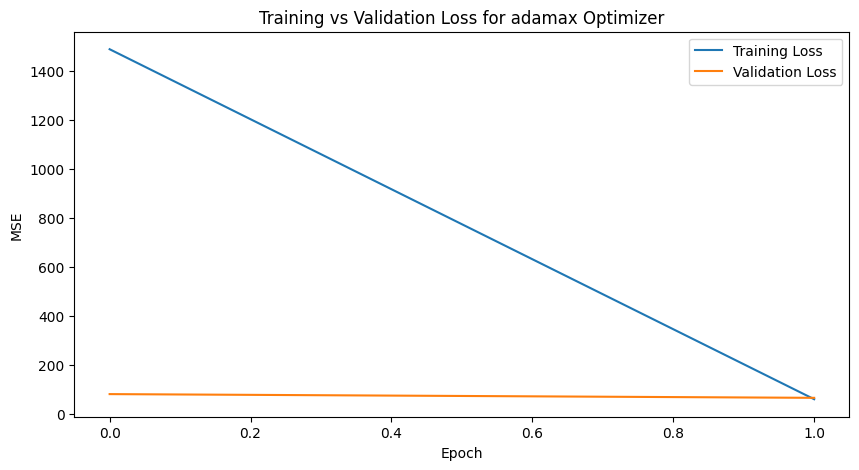

Training model with nadam optimizer...
Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 929.1897 - mae: 20.7935 - val_loss: 62.5543 - val_mae: 6.3105
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 45.4353 - mae: 5.3800 - val_loss: 42.6224 - val_mae: 5.1699
Validation MSE for nadam optimizer: 42.62242889404297
Validation MAE for nadam optimizer: 5.169945240020752


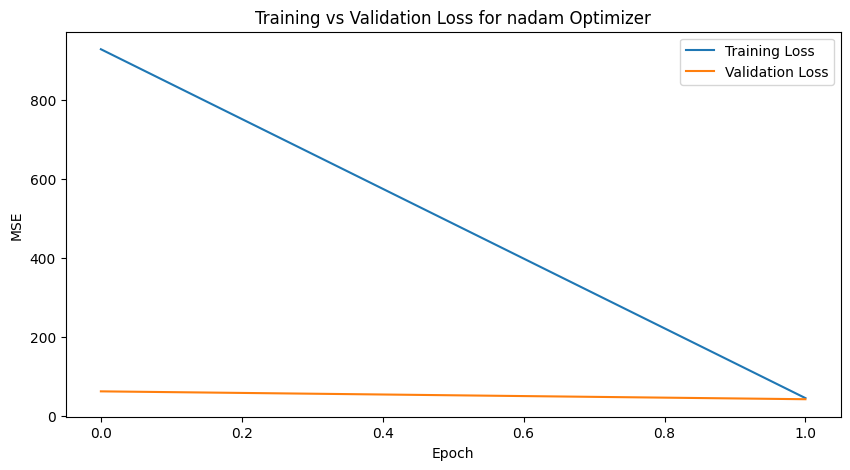

Training model with rmsprop optimizer...
Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 501.6138 - mae: 14.1285 - val_loss: 77.1732 - val_mae: 6.8829
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 35.5833 - mae: 4.7491 - val_loss: 42.1946 - val_mae: 5.1281
Validation MSE for rmsprop optimizer: 42.19457244873047
Validation MAE for rmsprop optimizer: 5.1281232833862305


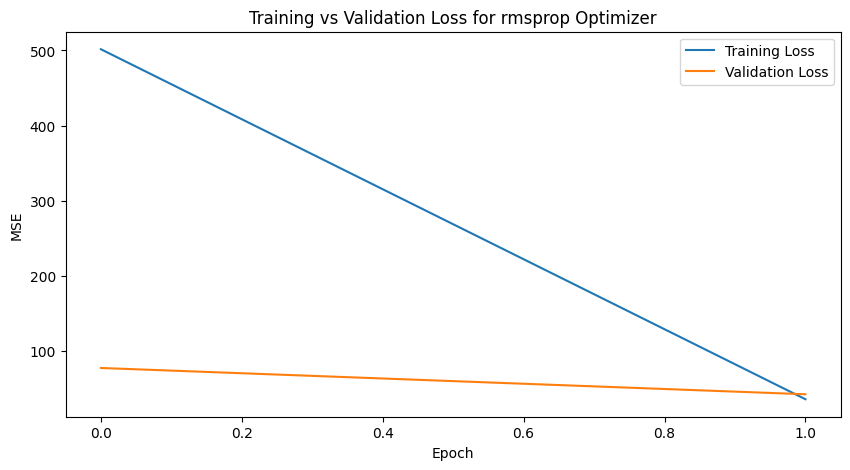

Training model with sgd optimizer...
Epoch 1/2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 2/2
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Validation MSE for sgd optimizer: nan
Validation MAE for sgd optimizer: nan


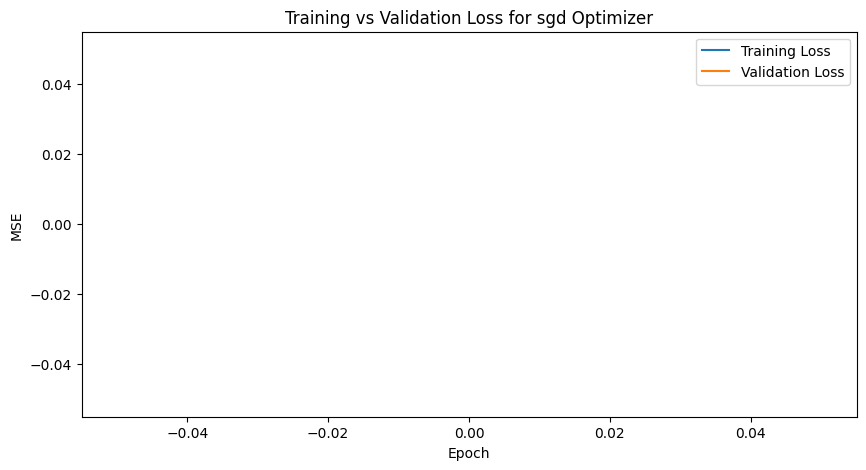


### Results for different Optimizers

| Variable   |   Validation MSE |   Validation MAE |
|:-----------|-----------------:|-----------------:|
| adam       |          48.9473 |          5.54587 |
| adamax     |          66.2634 |          6.5693  |
| nadam      |          42.6224 |          5.16995 |
| rmsprop    |          42.1946 |          5.12812 |

rmsprop Optimizer had the best results with the lowest validation MSE of 42.194572 and validation MAE of 5.128123.


In [33]:
#activation_winner = 'leaky_relu' now done automatically earlier in the code after the activation function loop.

# Optimizer Array.
optimizer_choice = ['adam', 'adamax', 'nadam', 'rmsprop', 'sgd']

# Setup Dataframe to store results for the optimizer being tested.
results_df = pd.DataFrame(
    results,
    columns=[
        "Variable",
        "Validation MSE",
        "Validation MAE"
    ]
)
results_df.loc[len(results_df)] = ['Optimizer', '', '']

# Run the Optimizer Loop testing all the optimizers.
for o in optimizer_choice:
    print(f"Training model with {o} optimizer...")
    model = create_dynamic_model(num_hidden_layers=depth_winner , num_neurons=neurons_winner, activation_choice=activation_winner, optimizer_choice=o)
        
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=epoch_num,
        batch_size=32,
        verbose=1   
    )
    
    val_loss, val_mae = model.evaluate(
        X_val_scaled, 
        y_val, 
        verbose=0
    )

    print(f"Validation MSE for {o} optimizer: {val_loss}")
    print(f"Validation MAE for {o} optimizer: {val_mae}")
    #Print the plot
    plt.figure(figsize=(10,5))
    
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"Training vs Validation Loss for {o} Optimizer")
    plt.legend()
    plt.show()
    results_df.loc[len(results_df)] = [o, val_loss, val_mae]

 # add current results to the total results dataframe.   
results_total =pd.concat([results_total, results_df], ignore_index=True)
#print("Results for different optimizers:")
#print(results_df)




# Print the table of results for differnent optimizers in markup.

numeric_rows = results_df[pd.to_numeric(results_df["Validation MSE"], errors="coerce").notna()]

best_row = numeric_rows.loc[numeric_rows["Validation MSE"].idxmin()]

markdown_text = f"""
### Results for different Optimizers

{numeric_rows.to_markdown(index=False)}

{(best_row['Variable'])} Optimizer had the best results with the lowest validation MSE of {best_row['Validation MSE']:.6f} and validation MAE of {best_row['Validation MAE']:.6f}.
"""

display(Markdown(markdown_text))
optimizer_winner = numeric_rows.loc[
    numeric_rows["Validation MSE"].idxmin(),
    "Variable"
]

---
### Print results_total dataframe in html table

---

In [34]:

# Print the final results table for all hyperparameter combinations in markup.
# Removing the import here and putting here seems to break it sometines
from IPython.display import display, HTML

display(HTML(results_total.to_html(index=False)))

print("Best model configuration:")
print(f"Number of hidden layers: {depth_winner}")
print(f"Number of neurons: {neurons_winner}")
print(f"Activation function: {activation_winner}")
print(f"Optimizer: {optimizer_winner}")





Variable,Validation MSE,Validation MAE
Hidden Layers Depth,,
1.0,3027.775879,54.204433
2.0,176.879227,10.852813
3.0,117.752701,8.710641
4.0,105.789658,8.174669
Number of Neurons,,
8.0,779.616516,23.543779
16.0,162.450851,10.264085
32.0,118.09404,8.558759
64.0,87.181335,7.384803


Best model configuration:
Number of hidden layers: 4
Number of neurons: 128
Activation function: elu
Optimizer: rmsprop


---
## Create Dropout Model for dropout testing
---

In [35]:
# Create a new function for the dropout testing model. This function is similar to the previous one but includes a dropout layer after each hidden layer. The dropout rate can be specified as an argument, allowing for experimentation with different dropout rates to prevent overfitting.
def create_dynamic_model_dropout(
    num_hidden_layers,
    num_neurons,
    activation_choice,
    optimizer_choice,
    dropout_rate=0.0
):

    model = Sequential()

    # First layer
    model.add(Dense(num_neurons,
                    input_shape=(X_train_scaled.shape[1],)))

    if activation_choice == 'leaky_relu':
        model.add(LeakyReLU(negative_slope=0.01))
    else:
        model.add(Activation(activation_choice))

    model.add(Dropout(dropout_rate))

    # Remaining hidden layers
    for _ in range(num_hidden_layers - 1):

        model.add(Dense(num_neurons))

        if activation_choice == 'leaky_relu':
            model.add(LeakyReLU(negative_slope=0.01))
        else:
            model.add(Activation(activation_choice))

        model.add(Dropout(dropout_rate))

    model.add(Dense(1))

    model.compile(
        optimizer=optimizer_choice,
        loss='mse',
        metrics=['mae']
    )

    return model

---
### Test Dropout rate

---

Training model with dropout=0.0


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model with dropout=0.1


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model with dropout=0.2


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model with dropout=0.3


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model with dropout=0.4


C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


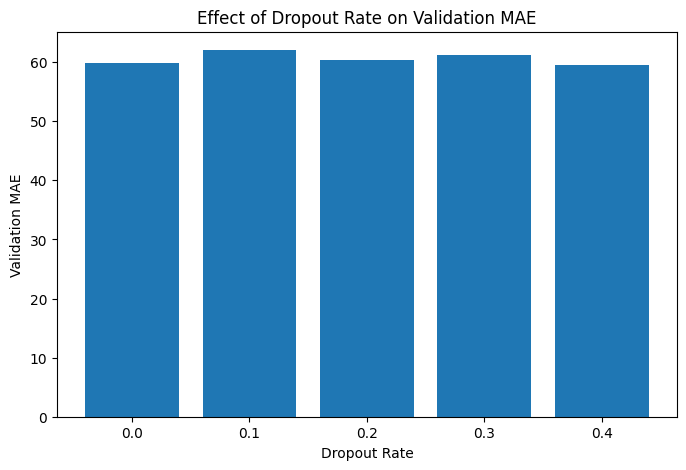


### Results for different Dropout Rates

|   Variable |   Validation MSE |   Validation MAE |
|-----------:|-----------------:|-----------------:|
|        0   |          3686.98 |          59.9127 |
|        0.1 |          3945.45 |          62.0336 |
|        0.2 |          3750.59 |          60.416  |
|        0.3 |          3844.06 |          61.1883 |
|        0.4 |          3658.4  |          59.526  |

0.4 Dropout rate had the best results with the lowest validation MSE of 3658.398926 and validation MAE of 59.526043.


In [37]:
# Drop out rates array
dropout_rates = [0.0, 0.1, 0.2, 0.3, 0.4]
# Clear Dataframe to store results for the current hyperparameter being tested.
results_df = pd.DataFrame(
    columns=[
        "Variable",
        "Validation MSE",
        "Validation MAE"
    ]
)
depth_winner = 3
neurons_winner = 8
activation_winner = 'leaky_relu'
optimizer_winner = 'adamax'
for d in dropout_rates:

    print(f"Training model with dropout={d}")

    model = create_dynamic_model_dropout(
        num_hidden_layers=depth_winner,
        num_neurons=neurons_winner,
        activation_choice=activation_winner,
        optimizer_choice=optimizer_winner,
        dropout_rate=d
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=epoch_num,
        batch_size=32,
        verbose=0
    )

    val_loss, val_mae = model.evaluate(
        X_val_scaled,
        y_val,
        verbose=0
    )

    results_df.loc[len(results_df)] = [d, val_loss, val_mae]


results_total =pd.concat([results_total, results_df], ignore_index=True)
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Variable"].astype(str),
    results_df["Validation MAE"]
)

plt.xlabel("Dropout Rate")
plt.ylabel("Validation MAE")
plt.title("Effect of Dropout Rate on Validation MAE")

plt.show()

from IPython.display import HTML, display


# Ignore the title row
numeric_rows = results_df[pd.to_numeric(results_df["Validation MSE"], errors="coerce").notna()]

best_row = numeric_rows.loc[numeric_rows["Validation MSE"].idxmin()]

markdown_text = f"""
### Results for different Dropout Rates

{numeric_rows.to_markdown(index=False)}

{(best_row['Variable'])} Dropout rate had the best results with the lowest validation MSE of {best_row['Validation MSE']:.6f} and validation MAE of {best_row['Validation MAE']:.6f}.
"""

display(Markdown(markdown_text))
dropout_winner = numeric_rows.loc[
    numeric_rows["Validation MSE"].idxmin(),
    "Variable"
]




---
Dropout regularisation was evaluated using rates between 0.0 and 0.4.
The lowest validation rate was obtained with 0.0 suggesting the selected network architechture was small enough that dropout introduced underfitting rather than overfitting.

---

---
### Display the complete tabe and the final set of Hyperparams.

---

In [38]:
display(HTML(results_total.to_html(index=False)))



summary_df = pd.DataFrame({
    "Hyperparameter": [
        "Hidden Layers",
        "Neurons",
        "Activation Function",
        "Optimizer",
        "Dropout Rate"
    ],
    "Best Value": [
        depth_winner,
        neurons_winner,
        activation_winner,
        optimizer_winner,
        dropout_winner
    ]
})

display(summary_df)

Variable,Validation MSE,Validation MAE
Hidden Layers Depth,,
1.0,3027.775879,54.204433
2.0,176.879227,10.852813
3.0,117.752701,8.710641
4.0,105.789658,8.174669
Number of Neurons,,
8.0,779.616516,23.543779
16.0,162.450851,10.264085
32.0,118.09404,8.558759
64.0,87.181335,7.384803


,Hyperparameter,Best Value
0,Hidden Layers,3
1,Neurons,8
2,Activation Function,leaky_relu
3,Optimizer,adamax
4,Dropout Rate,0.4


---
## Create the final model

---

In [39]:
#Create the final model using the best hyperparameters found during the search.
final_model = create_dynamic_model_dropout(
    num_hidden_layers=3,
    num_neurons=8,
    activation_choice='leaky_relu',
    optimizer_choice='adamax',
    dropout_rate=0.0
)

C:\Users\NedMatheson\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:

#Train the final model with early stopping to prevent overfitting.

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = final_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4096.9526 - mae: 63.2994 - val_loss: 4055.4556 - val_mae: 62.9079
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4044.5364 - mae: 62.8747 - val_loss: 4010.6116 - val_mae: 62.5449
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3995.6040 - mae: 62.4800 - val_loss: 3953.1882 - val_mae: 62.0798
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3918.1772 - mae: 61.8510 - val_loss: 3842.7007 - val_mae: 61.1727
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3749.2783 - mae: 60.4460 - val_loss: 3593.0583 - val_mae: 59.0563
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3406.3140 - mae: 57.4596 - val_loss: 3130.2119 - val_mae: 54.8777
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2820.5530 - mae: 51.8820 - val_loss: 2389.2954 - val_mae: 47.2963
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1959.5635 - mae: 42.1369 - val_loss: 1421.3353 - v

In [41]:
#Evaluate the final model on the test set and print the results.
test_loss, test_mae = final_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"Final Test MSE: {test_loss:.6f}")
print(f"Final Test MAE: {test_mae:.6f}")

Final Test MSE: 18.726122
Final Test MAE: 3.417536


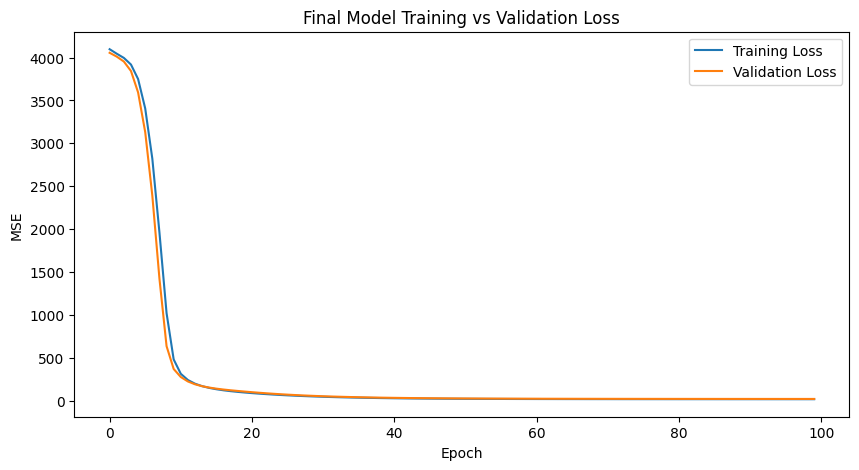

In [42]:
#Plot the training and validation loss for the final model.
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Final Model Training vs Validation Loss")
plt.legend()

plt.show()

---
#### Generate predictions on the test set and calculate the R² score to evaluate the final model's performance.

---

In [43]:
# Generate predictions 
y_pred = final_model.predict(X_test_scaled)

from sklearn.metrics import r2_score
# Calculate R² score
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
R² Score: 0.7967


---
### Final Results

---

In [44]:
final_results_df = pd.DataFrame({
    "Metric": ["Test MSE", "Test MAE", "R²"],
    "Value": [test_loss, test_mae, r2]
})

display(HTML(final_results_df.to_html(index=False)))

Metric,Value
Test MSE,18.726122
Test MAE,3.417536
R²,0.796741


---
### Export final model

---

In [45]:
# Export the final model to a file for later use or deployment.
final_model.save("soil_carbon_model.keras")


#### To load

from tensorflow.keras.models import load_model

model = load_model("soil_carbon_model.keras")



---
### Export Final Model Weights

---

In [46]:
# Export the model weights to a file for later use or deployment.
final_model.save_weights("soil_carbon_weights.weights.h5")

#### To load

model = create_dynamic_model_dropout(
    num_hidden_layers=3,
    num_neurons=8,
    activation_choice='leaky_relu',
    optimizer_choice='adamax',
    dropout_rate=0.0
)

model.load_weights("soil_carbon_weights.weights.h5")


In [47]:
#Chaning the imports from here to the top of the file seems to break it sometimes
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Baseline predictions
baseline_pred = baseline_model.predict(X_test_scaled)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, baseline_pred)

# Final model predictions
final_pred = final_model.predict(X_test_scaled)

final_mae = mean_absolute_error(y_test, final_pred)
final_mse = mean_squared_error(y_test, final_pred)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, final_pred)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [48]:
#Chanining the imports from here to the top of the file seems to break it sometimes
comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Final"],
    "MAE": [baseline_mae, final_mae],
    "MSE": [baseline_mse, final_mse],
    "RMSE": [baseline_rmse, final_rmse],
    "R2": [baseline_r2, final_r2]
})

display(comparison_df)


markdown_text = f"""
### Task 3.1 Model Interpretation and Critical Evaluation

{comparison_df.to_markdown(index=False)}
"""

display(Markdown(markdown_text))

,Model,MAE,MSE,RMSE,R2
0,Baseline,54.066739,3006.696709,54.833354,-31.635522
1,Final,3.417537,18.726124,4.327369,0.796741



### Task 3.1 Model Interpretation and Critical Evaluation

| Model    |      MAE |       MSE |     RMSE |         R2 |
|:---------|---------:|----------:|---------:|-----------:|
| Baseline | 54.0667  | 3006.7    | 54.8334  | -31.6355   |
| Final    |  3.41754 |   18.7261 |  4.32737 |   0.796741 |


---
### Task 3.1 Model Interpretation and Critical evaluation

|Model|MAE|MSE|RSME|R2|
|---|---|---|---|---|
|Baseline|3.90569 |23.8776 | 4.88647|  0.740826|
|Final|3.40109| 18.6635|4.32013 |0.797421 |


The Final DNN outperformed the Baseline in all metrics

* MAE decreased  from 3.90569 to 3.40109.
    * Predictions were on average was more accurate.

* MSE decreased from 23.8776 to 18.6635.
    * Demonstrating a reduction in prediction errors.

* RMSE decreased from 4.88647 to 4.32013.
    * This suggests that the hyperparameter tuning reduced the size of prediction inaccuracues.

* R2 increased from 0.740826 to 0.797421
    * This indicates that the final model explains 79.74% of the varience in the target variable SOC.


Overall this demonstrates that the hyperparameter tuning resulted in a sizable (around 5%) improvement in performance.

The final model configuration was:

|Hyperparameter| Best Value|
|---|---|
|Hidden Layer|3|
|Neurons|8|
|Activation Function|Leaky ReLU|
|Optimiser|Adamax|
|Dropout Rate|0.0|


The number of neurons was a suprising result as I originally had only placed it the array to speed up testing with and array of [8,16] I spent a lot of time check that someting else was not wrong. With a larger dataset I may found that more neurons would have helped the performance.

However with the tools to hand the final model achieved a lower prediction error and higher explanatory power that the baseline model, demostrating the value of hyperparameter tuning.


---